In [1]:
# Cell 1: Install all required libraries
!pip install gradio scikit-learn seaborn opencv-python-headless -q

print("✅ All libraries installed!")

✅ All libraries installed!


In [2]:
# Cell 2: Mount Google Drive & create permanent project folders
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_BASE    = '/content/drive/MyDrive/StrokeDetection'
DRIVE_DATASET = f'{DRIVE_BASE}/dataset'
DRIVE_MODELS  = f'{DRIVE_BASE}/models'
DRIVE_GRAPHS  = f'{DRIVE_BASE}/graphs'

for p in [
    f'{DRIVE_DATASET}/Normal',
    f'{DRIVE_DATASET}/Stroke',
    DRIVE_MODELS,
    DRIVE_GRAPHS
]:
    os.makedirs(p, exist_ok=True)

# ── Variables needed by Cell 15 (skipping training cells) ──
VGG_FINAL_PATH = f'{DRIVE_MODELS}/vgg19_final.keras'
EFF_FINAL_PATH = f'{DRIVE_MODELS}/eff_final.keras'
CLASS_INDICES  = {'Normal': 0, 'Stroke': 1}   # Keras sorts alphabetically: N=0, S=1

print("✅ Google Drive mounted & folders ready!")
print(f"\n   📁 {DRIVE_BASE}/")
print(f"      ├── dataset/Normal/")
print(f"      ├── dataset/Stroke/")
print(f"      ├── models/")
print(f"      └── graphs/")
print(f"\n   🔗 VGG path : {VGG_FINAL_PATH}")
print(f"   🔗 EFF path : {EFF_FINAL_PATH}")
print(f"   🏷️  Classes  : {CLASS_INDICES}")

Mounted at /content/drive
✅ Google Drive mounted & folders ready!

   📁 /content/drive/MyDrive/StrokeDetection/
      ├── dataset/Normal/
      ├── dataset/Stroke/
      ├── models/
      └── graphs/

   🔗 VGG path : /content/drive/MyDrive/StrokeDetection/models/vgg19_final.keras
   🔗 EFF path : /content/drive/MyDrive/StrokeDetection/models/eff_final.keras
   🏷️  Classes  : {'Normal': 0, 'Stroke': 1}


In [3]:
# Cell 3: Download all 3 datasets from Kaggle (smart skip if already on Drive)
import os, glob, zipfile

KAGGLE_TOKEN = "KGAT_0f7f866bc7b03a4230e392bba8035e72"  # your token
os.environ['KAGGLE_API_TOKEN'] = KAGGLE_TOKEN

drive_n = len(glob.glob(f'{DRIVE_DATASET}/Normal/*'))
drive_s = len(glob.glob(f'{DRIVE_DATASET}/Stroke/*'))

if drive_n > 5000 and drive_s > 2000:
    print(f"✅ Dataset already on Drive — skipping download!")
    print(f"   Normal : {drive_n}")
    print(f"   Stroke : {drive_s}")
    print(f"   Total  : {drive_n + drive_s}")
else:
    datasets = [
        ('afridirahman/brain-stroke-ct-image-dataset', '/content/ds1'),
        ('ozguraslank/brain-stroke-ct-dataset',        '/content/ds2'),
        ('subhajeetdas/brain-stroke-ct-dataset',       '/content/ds3'),
    ]

    for slug, dest in datasets:
        os.makedirs(dest, exist_ok=True)
        name = slug.split('/')[1]
        print(f"⬇️  Downloading {name}...")
        r = os.system(f'kaggle datasets download -d {slug} -p {dest} --force -q')
        print("✅ Done!" if r == 0 else "❌ Failed — check your token")

    print("\n📦 Extracting all datasets...")
    for i, (_, ds_dir) in enumerate(datasets, 1):
        raw = f'/content/raw{i}'
        os.makedirs(raw, exist_ok=True)
        for z in glob.glob(f'{ds_dir}/*.zip'):
            with zipfile.ZipFile(z, 'r') as zf:
                zf.extractall(raw)
        print(f"   ✅ raw{i} extracted!")

    print("\n📁 Folder structures found:")
    for i in range(1, 4):
        print(f"\n  raw{i}/")
        for root, dirs, files in os.walk(f'/content/raw{i}'):
            level = root.replace(f'/content/raw{i}', '').count(os.sep)
            if level < 3:
                print(f"    {'  '*level}{os.path.basename(root)}/  ({len(files)} files)")

✅ Dataset already on Drive — skipping download!
   Normal : 14832
   Stroke : 9842
   Total  : 24674


In [ ]:
# Cell 4: Check raw2 nested structure, merge all datasets → save to Drive
import shutil

# First check if raw2 has a nested zip inside External_Test
print("🔍 Checking raw2 for nested files...")
for root, dirs, files in os.walk('/content/raw2'):
    for f in files:
        fpath = os.path.join(root, f)
        print(f"   Found: {fpath}")
        if f.endswith('.zip'):
            print(f"   📦 Nested zip found! Extracting...")
            with zipfile.ZipFile(fpath, 'r') as zf:
                zf.extractall('/content/raw2_nested')
            print(f"   ✅ Extracted to /content/raw2_nested")

# Show raw2_nested structure if it exists
if os.path.exists('/content/raw2_nested'):
    print("\n📁 raw2_nested structure:")
    for root, dirs, files in os.walk('/content/raw2_nested'):
        level = root.replace('/content/raw2_nested', '').count(os.sep)
        if level < 4:
            print(f"    {'  '*level}{os.path.basename(root)}/  ({len(files)} files)")

print("\n✅ Investigation done!")

🔍 Checking raw2 for nested files...
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/10244.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/13905.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/12903.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/10042.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/11811.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/11708.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/15651.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/11508.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/10615.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/10617.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/11446.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/14580.dcm
   Found: /content/raw2/Brain_Stroke_CT_Dataset/Normal/DICOM/10237.dcm
   Found: /content/raw2/Brain_Stroke_CT_D

In [ ]:
# Cell 5: Merge all datasets → save permanently to Google Drive (smart skip)
import shutil

drive_n = len(glob.glob(f'{DRIVE_DATASET}/Normal/*'))
drive_s = len(glob.glob(f'{DRIVE_DATASET}/Stroke/*'))

if drive_n > 5000 and drive_s > 2000:
    print(f"✅ Merged dataset already on Drive — skipping!")
    print(f"   Normal : {drive_n}")
    print(f"   Stroke : {drive_s}")
    print(f"   Total  : {drive_n + drive_s}")
else:
    def copy_images(source_dirs, dest_dir):
        count = 0
        existing = set(os.listdir(dest_dir))
        for src in source_dirs:
            for img in glob.glob(f'{src}/**/*', recursive=True):
                if img.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                    fname = os.path.basename(img)
                    if fname in existing:
                        base, ext = os.path.splitext(fname)
                        fname = f'{base}_{count}{ext}'
                    shutil.copy(img, os.path.join(dest_dir, fname))
                    existing.add(fname)
                    count += 1
        return count

    # ── Dataset 1 (afridirahman): Normal + Stroke ──
    n1 = copy_images(glob.glob('/content/raw1/**/Normal', recursive=True) +
                     glob.glob('/content/raw1/**/normal', recursive=True),
                     f'{DRIVE_DATASET}/Normal')
    s1 = copy_images(glob.glob('/content/raw1/**/Stroke', recursive=True) +
                     glob.glob('/content/raw1/**/stroke', recursive=True),
                     f'{DRIVE_DATASET}/Stroke')
    print(f"✅ Dataset 1 (afridirahman) → Normal: {n1}  Stroke: {s1}")

    # ── Dataset 2 (ozguraslank): Normal/PNG + Bleeding/PNG→Stroke + Ischemia/PNG→Stroke ──
    n2 = copy_images(glob.glob('/content/raw2/**/Normal/PNG', recursive=True) +
                     glob.glob('/content/raw2/**/Normal', recursive=True),
                     f'{DRIVE_DATASET}/Normal')
    s2 = copy_images(glob.glob('/content/raw2/**/Bleeding/PNG', recursive=True) +
                     glob.glob('/content/raw2/**/Bleeding', recursive=True) +
                     glob.glob('/content/raw2/**/Ischemia/PNG', recursive=True) +
                     glob.glob('/content/raw2/**/Ischemia', recursive=True),
                     f'{DRIVE_DATASET}/Stroke')
    print(f"✅ Dataset 2 (ozguraslank) → Normal: {n2}  Stroke (Bleeding+Ischemia): {s2}")

    # ── Dataset 3 (subhajeetdas): Normal + Bleeding→Stroke + Ischemia→Stroke ──
    n3 = copy_images(glob.glob('/content/raw3/**/Normal', recursive=True) +
                     glob.glob('/content/raw3/**/normal', recursive=True),
                     f'{DRIVE_DATASET}/Normal')
    s3 = copy_images(glob.glob('/content/raw3/**/Bleeding', recursive=True) +
                     glob.glob('/content/raw3/**/bleeding', recursive=True) +
                     glob.glob('/content/raw3/**/Ischemia', recursive=True) +
                     glob.glob('/content/raw3/**/ischemia', recursive=True),
                     f'{DRIVE_DATASET}/Stroke')
    print(f"✅ Dataset 3 (subhajeetdas) → Normal: {n3}  Stroke (Bleeding+Ischemia): {s3}")

    total_n = len(glob.glob(f'{DRIVE_DATASET}/Normal/*'))
    total_s = len(glob.glob(f'{DRIVE_DATASET}/Stroke/*'))
    print(f"\n✅ All datasets merged & permanently saved to Google Drive!")
    print(f"   TOTAL Normal : {total_n}")
    print(f"   TOTAL Stroke : {total_s}")
    print(f"   GRAND TOTAL  : {total_n + total_s}")

✅ Dataset 1 (afridirahman) → Normal: 1551  Stroke: 950
✅ Dataset 2 (ozguraslank) → Normal: 8854  Stroke (Bleeding+Ischemia): 6669
✅ Dataset 3 (subhajeetdas) → Normal: 4427  Stroke (Bleeding+Ischemia): 2223

✅ All datasets merged & permanently saved to Google Drive!
   TOTAL Normal : 14832
   TOTAL Stroke : 9842
   GRAND TOTAL  : 24674


In [ ]:
# Cell 6: Copy dataset from Drive → local /content/ for fast training
# (Drive is permanent but slow; local SSD is fast)

LOCAL_DATASET = '/content/dataset'
os.makedirs(f'{LOCAL_DATASET}/Normal', exist_ok=True)
os.makedirs(f'{LOCAL_DATASET}/Stroke', exist_ok=True)

local_n = len(glob.glob(f'{LOCAL_DATASET}/Normal/*'))
local_s = len(glob.glob(f'{LOCAL_DATASET}/Stroke/*'))
drive_n = len(glob.glob(f'{DRIVE_DATASET}/Normal/*'))
drive_s = len(glob.glob(f'{DRIVE_DATASET}/Stroke/*'))

if local_n >= drive_n and local_s >= drive_s:
    print(f"✅ Local dataset already ready — skipping copy!")
    print(f"   Normal : {local_n}")
    print(f"   Stroke : {local_s}")
    print(f"   Total  : {local_n + local_s}")
else:
    print(f"📋 Copying Drive → local /content/dataset/")
    print(f"   This is a one-time copy per session...")
    os.system(f'rsync -a {DRIVE_DATASET}/ {LOCAL_DATASET}/')
    local_n = len(glob.glob(f'{LOCAL_DATASET}/Normal/*'))
    local_s = len(glob.glob(f'{LOCAL_DATASET}/Stroke/*'))
    print(f"\n✅ Done!")
    print(f"   Normal : {local_n}")
    print(f"   Stroke : {local_s}")
    print(f"   Total  : {local_n + local_s}")

📋 Copying Drive → local /content/dataset/
   This is a one-time copy per session...

✅ Done!
   Normal : 14832
   Stroke : 9842
   Total  : 24674


In [ ]:
# Cell 7: All imports and constants
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2
import warnings
warnings.filterwarnings('ignore')

from tensorflow.keras.applications import VGG19, EfficientNetB4
from tensorflow.keras.applications.vgg19       import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers     import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
from tensorflow.keras.models     import Model, load_model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks  import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.utils.class_weight  import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE   = (224, 224)
BATCH_SIZE = 16
EPOCHS_P1  = 20
EPOCHS_P2  = 15
DATASET    = '/content/dataset'

VGG_FINAL_PATH = f'{DRIVE_MODELS}/vgg19_final.keras'
EFF_FINAL_PATH = f'{DRIVE_MODELS}/eff_final.keras'

print("GPU    :", tf.config.list_physical_devices('GPU'))
print("TF     :", tf.__version__)
print(f"Models will be saved to → {DRIVE_MODELS}/")
print("✅ Ready!")

GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF     : 2.19.0
Models will be saved to → /content/drive/MyDrive/StrokeDetection/models/
✅ Ready!


In [ ]:
# Cell 8: Build data generators
def make_generators(preprocess_fn, dataset_dir, img_size, batch_size):
    train_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        rotation_range=20,
        width_shift_range=0.1,
        height_shift_range=0.1,
        shear_range=0.1,
        zoom_range=0.15,
        horizontal_flip=True,
        brightness_range=(0.85, 1.15),
        fill_mode='nearest',
        validation_split=0.2
    ).flow_from_directory(
        dataset_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='training', shuffle=True, seed=42
    )
    val_gen = ImageDataGenerator(
        preprocessing_function=preprocess_fn,
        validation_split=0.2
    ).flow_from_directory(
        dataset_dir, target_size=img_size, batch_size=batch_size,
        class_mode='categorical', subset='validation', shuffle=False, seed=42
    )
    return train_gen, val_gen

vgg_train, vgg_val = make_generators(vgg_preprocess, DATASET, IMG_SIZE, BATCH_SIZE)
eff_train, eff_val = make_generators(eff_preprocess, DATASET, IMG_SIZE, BATCH_SIZE)

CLASS_INDICES     = vgg_train.class_indices
INV_CLASS_INDICES = {v: k for k, v in CLASS_INDICES.items()}
NUM_CLASSES       = len(CLASS_INDICES)

labels       = vgg_train.classes
cw           = compute_class_weight('balanced', classes=np.unique(labels), y=labels)
CLASS_WEIGHT = dict(enumerate(cw))

print(f"✅ Generators ready!")
print(f"   Classes       : {CLASS_INDICES}")
print(f"   Class weights : {CLASS_WEIGHT}")
print(f"   Train samples : {vgg_train.samples}")
print(f"   Val samples   : {vgg_val.samples}")

Found 19740 images belonging to 2 classes.
Found 4934 images belonging to 2 classes.
Found 19740 images belonging to 2 classes.
Found 4934 images belonging to 2 classes.
✅ Generators ready!
   Classes       : {'Normal': 0, 'Stroke': 1}
   Class weights : {0: np.float64(0.8317883027136356), 1: np.float64(1.253492506985014)}
   Train samples : 19740
   Val samples   : 4934


In [ ]:
# Cell 9: Define model architectures
def build_vgg19(num_classes, img_size):
    base = VGG19(include_top=False, weights='imagenet', input_shape=img_size + (3,))
    base.trainable = False
    x   = GlobalAveragePooling2D()(base.output)
    x   = Dense(512, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.5)(x)
    x   = Dense(256, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)
    m   = Model(base.input, out, name='VGG19_Stroke')
    m.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return m

def build_efficientnet(num_classes, img_size):
    base = EfficientNetB4(include_top=False, weights='imagenet', input_shape=img_size + (3,))
    base.trainable = False
    x   = GlobalAveragePooling2D()(base.output)
    x   = Dense(512, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.5)(x)
    x   = Dense(256, activation='relu')(x)
    x   = BatchNormalization()(x)
    x   = Dropout(0.4)(x)
    out = Dense(num_classes, activation='softmax')(x)
    m   = Model(base.input, out, name='EfficientNetB4_Stroke')
    m.compile(optimizer=Adam(1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return m

print("✅ Model architectures defined!")
print(f"   VGG19          → will save to: {VGG_FINAL_PATH}")
print(f"   EfficientNetB4 → will save to: {EFF_FINAL_PATH}")

✅ Model architectures defined!
   VGG19          → will save to: /content/drive/MyDrive/StrokeDetection/models/vgg19_final.keras
   EfficientNetB4 → will save to: /content/drive/MyDrive/StrokeDetection/models/eff_final.keras


In [ ]:
# Cell 10: Define callbacks — all checkpoints save to Google Drive
def get_callbacks(model_name):
    return [
        EarlyStopping(
            monitor='val_accuracy', patience=6,
            restore_best_weights=True, verbose=1
        ),
        ModelCheckpoint(
            f'{DRIVE_MODELS}/{model_name}.keras',   # ← saves to Google Drive!
            monitor='val_accuracy',
            save_best_only=True,
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss', factor=0.5,
            patience=3, min_lr=1e-7, verbose=1
        )
    ]

print("✅ Callbacks ready!")
print(f"   All checkpoints → {DRIVE_MODELS}/")

✅ Callbacks ready!
   All checkpoints → /content/drive/MyDrive/StrokeDetection/models/


In [ ]:
# Cell 11: Train VGG19 or load directly from Drive if already trained
if os.path.exists(VGG_FINAL_PATH):
    print("✅ VGG19 found on Google Drive — loading directly!")
    print("   ⏩ Skipping training entirely.")
    vgg_model = load_model(VGG_FINAL_PATH)
    vgg_loss, vgg_acc = vgg_model.evaluate(vgg_val, verbose=0)
    print(f"   Val Accuracy : {vgg_acc*100:.2f}%")
else:
    print("🔄 VGG19 not found on Drive — training from scratch...\n")
    vgg_model = build_vgg19(NUM_CLASSES, IMG_SIZE)

    # ── Phase 1: train head only (backbone frozen) ──
    print("=" * 55)
    print("  VGG19 — PHASE 1: Head only (backbone frozen)")
    print("=" * 55)
    vgg_h1 = vgg_model.fit(
        vgg_train,
        steps_per_epoch  = vgg_train.samples  // BATCH_SIZE,
        epochs           = EPOCHS_P1,
        validation_data  = vgg_val,
        validation_steps = vgg_val.samples // BATCH_SIZE,
        callbacks        = get_callbacks('vgg19_p1'),
        class_weight     = CLASS_WEIGHT
    )
    p1_best = max(vgg_h1.history['val_accuracy']) * 100
    print(f"\n✅ Phase 1 done! Best val accuracy: {p1_best:.2f}%")

    # ── Phase 2: fine-tune block5 layers ──
    for layer in vgg_model.layers:
        layer.trainable = (
            layer.name.startswith('block5') or
            isinstance(layer, (Dense, BatchNormalization,
                               Dropout, GlobalAveragePooling2D))
        )
    vgg_model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n" + "=" * 55)
    print("  VGG19 — PHASE 2: Fine-tuning block5 layers")
    print("=" * 55)
    vgg_h2 = vgg_model.fit(
        vgg_train,
        steps_per_epoch  = vgg_train.samples  // BATCH_SIZE,
        epochs           = EPOCHS_P2,
        validation_data  = vgg_val,
        validation_steps = vgg_val.samples // BATCH_SIZE,
        callbacks        = get_callbacks('vgg19_final'),
        class_weight     = CLASS_WEIGHT
    )
    p2_best = max(vgg_h2.history['val_accuracy']) * 100
    print(f"\n✅ Phase 2 done! Best val accuracy: {p2_best:.2f}%")

    vgg_model = load_model(VGG_FINAL_PATH)
    vgg_loss, vgg_acc = vgg_model.evaluate(vgg_val, verbose=0)
    print(f"\n✅ Best VGG19 reloaded from Drive!")
    print(f"   Val Accuracy : {vgg_acc*100:.2f}%")

🔄 VGG19 not found on Drive — training from scratch...

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
  VGG19 — PHASE 1: Head only (backbone frozen)
Epoch 1/20
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step - accuracy: 0.7071 - loss: 0.6670
Epoch 1: val_accuracy improved from None to 0.83157, saving model to /content/drive/MyDrive/StrokeDetection/models/vgg19_p1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/StrokeDetection/models/vgg19_p1.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 455s 359ms/step - accuracy: 0.7484 - loss: 0.5485 - val_accuracy: 0.8316 - val_loss: 0.3794 - learning_rate: 0.0010
Epoch 2/20
   1/1233 ━━━━━━━━━━━━━━━━━━━━ 2:21 115ms/step - accuracy: 0.6875 - loss: 0.5543
Epoch 2: val_accuracy did not improve from 0.83157
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 38s 31ms/step - accuracy: 0.6875 - loss: 0.5543 - val_accuracy: 0.8308 - val_loss: 0.3779 - learning_rate: 0.0010
Epoch 3/20
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 316ms/step - accuracy: 0.7979 - loss: 0.4410
Epoch 

In [ ]:
# Cell 12: Train EfficientNetB4 or load directly from Drive if already trained
if os.path.exists(EFF_FINAL_PATH):
    print("✅ EfficientNetB4 found on Google Drive — loading directly!")
    print("   ⏩ Skipping training entirely.")
    eff_model = load_model(EFF_FINAL_PATH)
    eff_loss, eff_acc = eff_model.evaluate(eff_val, verbose=0)
    print(f"   Val Accuracy : {eff_acc*100:.2f}%")
else:
    print("🔄 EfficientNetB4 not found on Drive — training from scratch...\n")
    eff_model = build_efficientnet(NUM_CLASSES, IMG_SIZE)

    # ── Phase 1: train head only (backbone frozen) ──
    print("=" * 55)
    print("  EfficientNetB4 — PHASE 1: Head only (backbone frozen)")
    print("=" * 55)
    eff_h1 = eff_model.fit(
        eff_train,
        steps_per_epoch  = eff_train.samples  // BATCH_SIZE,
        epochs           = EPOCHS_P1,
        validation_data  = eff_val,
        validation_steps = eff_val.samples // BATCH_SIZE,
        callbacks        = get_callbacks('eff_p1'),
        class_weight     = CLASS_WEIGHT
    )
    p1_best = max(eff_h1.history['val_accuracy']) * 100
    print(f"\n✅ Phase 1 done! Best val accuracy: {p1_best:.2f}%")

    # ── Phase 2: fine-tune last 40 layers ──
    for layer in eff_model.layers:
        layer.trainable = False
    for layer in eff_model.layers[-40:]:
        layer.trainable = True
    eff_model.compile(
        optimizer=Adam(1e-4),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    print("\n" + "=" * 55)
    print("  EfficientNetB4 — PHASE 2: Fine-tuning last 40 layers")
    print("=" * 55)
    eff_h2 = eff_model.fit(
        eff_train,
        steps_per_epoch  = eff_train.samples  // BATCH_SIZE,
        epochs           = EPOCHS_P2,
        validation_data  = eff_val,
        validation_steps = eff_val.samples // BATCH_SIZE,
        callbacks        = get_callbacks('eff_final'),
        class_weight     = CLASS_WEIGHT
    )
    p2_best = max(eff_h2.history['val_accuracy']) * 100
    print(f"\n✅ Phase 2 done! Best val accuracy: {p2_best:.2f}%")

    eff_model = load_model(EFF_FINAL_PATH)
    eff_loss, eff_acc = eff_model.evaluate(eff_val, verbose=0)
    print(f"\n✅ Best EfficientNetB4 reloaded from Drive!")
    print(f"   Val Accuracy : {eff_acc*100:.2f}%")

🔄 EfficientNetB4 not found on Drive — training from scratch...

71686520/71686520 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
  EfficientNetB4 — PHASE 1: Head only (backbone frozen)
Epoch 1/20
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 0s 307ms/step - accuracy: 0.6945 - loss: 0.6864
Epoch 1: val_accuracy improved from None to 0.84334, saving model to /content/drive/MyDrive/StrokeDetection/models/eff_p1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/StrokeDetection/models/eff_p1.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 477s 337ms/step - accuracy: 0.7344 - loss: 0.5716 - val_accuracy: 0.8433 - val_loss: 0.3582 - learning_rate: 0.0010
Epoch 2/20
   1/1233 ━━━━━━━━━━━━━━━━━━━━ 1:33 76ms/step - accuracy: 0.9375 - loss: 0.2760
Epoch 2: val_accuracy improved from 0.84334 to 0.84476, saving model to /content/drive/MyDrive/StrokeDetection/models/eff_p1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/StrokeDetection/models/eff_p1.keras
1233/1233 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accurac

In [ ]:
# Cell 13: Find best ensemble weights & evaluate on validation set
import numpy as np
from itertools import product

print("🔍 Finding best ensemble weights...\n")

# Get predictions from both models
vgg_preds  = vgg_model.predict(vgg_val, verbose=1)
eff_preds  = eff_model.predict(eff_val, verbose=1)
true_labels = vgg_val.classes

best_acc    = 0
best_vgg_w  = 0.7
best_eff_w  = 0.3

# Grid search over weights
for vgg_w in np.arange(0.5, 1.01, 0.05):
    eff_w = round(1.0 - vgg_w, 2)
    ensemble_preds = vgg_w * vgg_preds + eff_w * eff_preds
    preds          = np.argmax(ensemble_preds, axis=1)
    acc            = np.mean(preds == true_labels) * 100
    if acc > best_acc:
        best_acc   = acc
        best_vgg_w = round(vgg_w, 2)
        best_eff_w = round(eff_w, 2)

print(f"\n{'='*50}")
print(f"  📊 FINAL RESULTS SUMMARY")
print(f"{'='*50}")
print(f"  VGG19 alone          : {vgg_acc*100:.2f}%")
print(f"  EfficientNetB4 alone : {eff_acc*100:.2f}%")
print(f"  Best Ensemble        : {best_acc:.2f}%  🏆")
print(f"  Best Weights         : VGG={best_vgg_w}  EFF={best_eff_w}")
print(f"{'='*50}")

# Save best weights to Drive for Gradio to use
import json
weights = {'vgg_w': best_vgg_w, 'eff_w': best_eff_w}
with open(f'{DRIVE_MODELS}/ensemble_weights.json', 'w') as f:
    json.dump(weights, f)
print(f"\n✅ Ensemble weights saved to Drive!")

🔍 Finding best ensemble weights...

309/309 ━━━━━━━━━━━━━━━━━━━━ 43s 133ms/step
309/309 ━━━━━━━━━━━━━━━━━━━━ 47s 117ms/step

  📊 FINAL RESULTS SUMMARY
  VGG19 alone          : 94.97%
  EfficientNetB4 alone : 92.28%
  Best Ensemble        : 95.48%  🏆
  Best Weights         : VGG=0.55  EFF=0.45

✅ Ensemble weights saved to Drive!


309/309 ━━━━━━━━━━━━━━━━━━━━ 47s 153ms/step
309/309 ━━━━━━━━━━━━━━━━━━━━ 24s 79ms/step


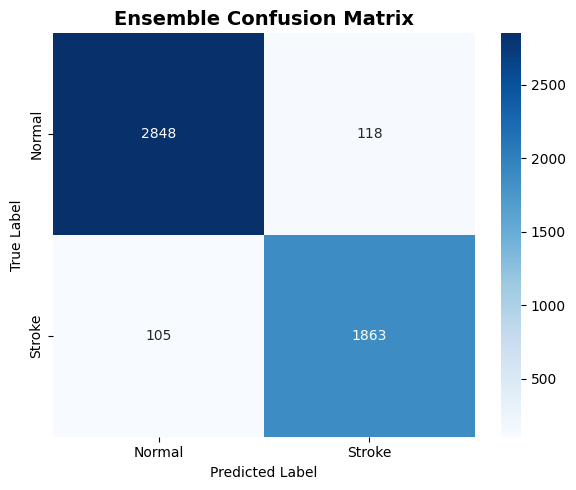

✅ Confusion matrix saved to Drive!

📊 Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.96      0.96      2966
      Stroke       0.94      0.95      0.94      1968

    accuracy                           0.95      4934
   macro avg       0.95      0.95      0.95      4934
weighted avg       0.95      0.95      0.95      4934

✅ Classification report saved to Drive!


In [ ]:
# Cell 14: Confusion matrix + classification report → saved to Drive
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np, json

# Load best ensemble weights
with open(f'{DRIVE_MODELS}/ensemble_weights.json') as f:
    w = json.load(f)
vgg_w, eff_w = w['vgg_w'], w['eff_w']

# Ensemble predictions
vgg_preds  = vgg_model.predict(vgg_val, verbose=1)
eff_preds  = eff_model.predict(eff_val, verbose=1)
ens_preds  = vgg_w * vgg_preds + eff_w * eff_preds
y_pred     = np.argmax(ens_preds, axis=1)
y_true     = vgg_val.classes
class_names = list(INV_CLASS_INDICES[i] for i in sorted(INV_CLASS_INDICES))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Ensemble Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig(f'{DRIVE_GRAPHS}/confusion_matrix.png', dpi=150)
plt.show()
print("✅ Confusion matrix saved to Drive!")

# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("\n📊 Classification Report:")
print("=" * 55)
print(report)

# Save report to Drive
with open(f'{DRIVE_GRAPHS}/classification_report.txt', 'w') as f:
    f.write(f"Ensemble Weights — VGG19: {vgg_w}  EfficientNetB4: {eff_w}\n\n")
    f.write(report)
print("✅ Classification report saved to Drive!")


In [4]:
# Cell 15: Gradio UI — loads models from Drive permanently
import os, cv2, json, numpy as np, warnings
warnings.filterwarnings('ignore')
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.vgg19 import preprocess_input as vgg_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
import gradio as gr

IMG_SIZE = (224, 224)

# ── Safety check before loading ──
print("🔍 Verifying files on Drive...")
for fpath in [VGG_FINAL_PATH, EFF_FINAL_PATH, f'{DRIVE_MODELS}/ensemble_weights.json']:
    exists = "✅" if os.path.exists(fpath) else "❌ MISSING"
    print(f"   {exists} — {fpath}")

# ── Load ensemble weights from Drive ──
with open(f'{DRIVE_MODELS}/ensemble_weights.json') as f:
    w = json.load(f)
VGG_WEIGHT = w['vgg_w']
EFF_WEIGHT = w['eff_w']

INV_CLASS_INDICES = {v: k for k, v in CLASS_INDICES.items()}

# ── Load models from Drive ──
print("⏳ Loading models from Drive...")
vgg_model = load_model(VGG_FINAL_PATH)
eff_model = load_model(EFF_FINAL_PATH)
print("✅ Models loaded!")
print(f"   Classes         : {CLASS_INDICES}")
print(f"   Ensemble weights: VGG={VGG_WEIGHT}  EFF={EFF_WEIGHT}")

def predict_stroke(image):
    if image is None:
        return "<div style='background:#0d1b3e;border-radius:16px;padding:40px;text-align:center;border:1px solid #1e3a6e'><div style='font-size:40px'>🧠</div><p style='color:#4a6080;margin-top:12px'>Upload a brain scan and click Analyse</p></div>"

    img      = cv2.resize(image.astype('float32'), IMG_SIZE)
    vgg_pred = vgg_model.predict(vgg_preprocess(np.expand_dims(img.copy(), 0)), verbose=0)[0]
    eff_pred = eff_model.predict(eff_preprocess(np.expand_dims(img.copy(), 0)), verbose=0)[0]
    ensemble = VGG_WEIGHT * vgg_pred + EFF_WEIGHT * eff_pred

    pred_idx   = int(np.argmax(ensemble))
    pred_label = INV_CLASS_INDICES[pred_idx]
    confidence = float(ensemble[pred_idx]) * 100
    vgg_conf   = float(vgg_pred[pred_idx]) * 100
    eff_conf   = float(eff_pred[pred_idx]) * 100
    is_stroke  = pred_label.lower() == 'stroke'

    status_color = "#ff4444" if is_stroke else "#00cc88"
    status_bg    = "rgba(255,68,68,0.1)" if is_stroke else "rgba(0,204,136,0.1)"
    status_icon  = "🔴" if is_stroke else "🟢"
    status_text  = "STROKE DETECTED" if is_stroke else "NORMAL"
    border_color = "#ff4444" if is_stroke else "#00cc88"
    recommendation = (
        "Urgent medical attention is required. Please consult a neurologist immediately. "
        "Time is critical in stroke treatment — every minute matters. "
        "Contact emergency services or visit the nearest hospital right away."
        if is_stroke else
        "No stroke indicators detected in this scan. "
        "However, this AI tool is not a substitute for professional medical diagnosis. "
        "If symptoms persist or worsen, please consult a qualified neurologist."
    )
    warn_text = "<p style='color:#ffaa00;font-size:13px;margin-top:8px'>⚠️ Low confidence — please consult a doctor regardless of result</p>" if confidence < 70 else ""

    return f"""
    <div style='font-family:Inter,sans-serif;background:#0d1b3e;border-radius:16px;padding:24px;border:1px solid #1e3a6e'>
      <div style='background:{status_bg};border:2px solid {border_color};border-radius:12px;padding:20px;text-align:center;margin-bottom:20px'>
        <div style='font-size:42px;margin-bottom:8px'>{status_icon}</div>
        <div style='color:{status_color};font-size:28px;font-weight:700;letter-spacing:2px'>{status_text}</div>
        <div style='color:#a0b4d0;font-size:14px;margin-top:4px'>Ensemble Prediction (VGG19 + EfficientNetB4)</div>
      </div>
      <div style='margin-bottom:20px'>
        <div style='display:flex;justify-content:space-between;margin-bottom:6px'>
          <span style='color:#a0b4d0;font-size:14px'>Overall Confidence</span>
          <span style='color:white;font-weight:600;font-size:14px'>{confidence:.1f}%</span>
        </div>
        <div style='background:#1a2f5e;border-radius:999px;height:10px'>
          <div style='background:{status_color};height:10px;border-radius:999px;width:{min(confidence,100):.1f}%'></div>
        </div>
        {warn_text}
      </div>
      <div style='background:#0a1628;border-radius:12px;padding:16px;margin-bottom:20px'>
        <div style='color:#a0b4d0;font-size:12px;letter-spacing:1px;margin-bottom:12px'>INDIVIDUAL MODEL RESULTS</div>
        <div style='margin-bottom:12px'>
          <div style='display:flex;justify-content:space-between;margin-bottom:5px'>
            <span style='color:#00d4ff;font-size:13px'>🔷 VGG19</span>
            <span style='color:white;font-size:13px'>{INV_CLASS_INDICES[int(np.argmax(vgg_pred))].upper()} — {vgg_conf:.1f}%</span>
          </div>
          <div style='background:#1a2f5e;border-radius:999px;height:7px'>
            <div style='background:#00d4ff;height:7px;border-radius:999px;width:{min(vgg_conf,100):.1f}%'></div>
          </div>
        </div>
        <div>
          <div style='display:flex;justify-content:space-between;margin-bottom:5px'>
            <span style='color:#a78bfa;font-size:13px'>🔶 EfficientNetB4</span>
            <span style='color:white;font-size:13px'>{INV_CLASS_INDICES[int(np.argmax(eff_pred))].upper()} — {eff_conf:.1f}%</span>
          </div>
          <div style='background:#1a2f5e;border-radius:999px;height:7px'>
            <div style='background:#a78bfa;height:7px;border-radius:999px;width:{min(eff_conf,100):.1f}%'></div>
          </div>
        </div>
      </div>
      <div style='background:#0a1628;border-radius:12px;padding:16px;margin-bottom:16px;border-left:3px solid {border_color}'>
        <div style='color:#a0b4d0;font-size:12px;letter-spacing:1px;margin-bottom:8px'>⚕️ RECOMMENDATION</div>
        <div style='color:#e2e8f0;font-size:14px;line-height:1.6'>{recommendation}</div>
      </div>
      <div style='text-align:center;color:#4a6080;font-size:11px'>⚠️ For educational & research purposes only. Not a substitute for medical diagnosis.</div>
    </div>"""

custom_css = """
    body, .gradio-container { background: #0a0f2e !important; font-family: Inter, sans-serif !important; }
    .gradio-container { max-width: 1100px !important; margin: 0 auto !important; }
    footer { display: none !important; }
    button.lg { background: #00d4ff !important; color: #0a0f2e !important; font-weight: 700 !important; border: none !important; border-radius: 8px !important; }
"""

header_html = """
<div style='background:linear-gradient(135deg,#0a0f2e,#0d1b3e);padding:32px;border-radius:16px;border:1px solid #1e3a6e;margin-bottom:8px;text-align:center'>
  <div style='font-size:48px;margin-bottom:8px'>🧠</div>
  <h1 style='color:#00d4ff;font-size:26px;font-weight:800;margin:0;letter-spacing:2px'>STROKE DETECTION USING CT/MRI SCANS</h1>
  <p style='color:#a0b4d0;margin:8px 0 4px;font-size:14px'>Department of Information Technology &nbsp;|&nbsp; Dr. N.G.P Institute of Technology</p>
  <p style='color:#4a6080;font-size:12px;margin:4px 0'>Supervisor: Ms. R. Ramya, Assistant Professor (SG)</p>
  <div style='display:flex;justify-content:center;gap:12px;margin-top:12px;flex-wrap:wrap'>
    <span style='background:#1a2f5e;color:#a0b4d0;padding:4px 12px;border-radius:999px;font-size:12px'>Logeshwari R — 710723205036</span>
    <span style='background:#1a2f5e;color:#a0b4d0;padding:4px 12px;border-radius:999px;font-size:12px'>Samyukta A — 710723205051</span>
    <span style='background:#1a2f5e;color:#a0b4d0;padding:4px 12px;border-radius:999px;font-size:12px'>Sarvesh P — 710723205052</span>
    <span style='background:#1a2f5e;color:#a0b4d0;padding:4px 12px;border-radius:999px;font-size:12px'>Varsha N — 710723205061</span>
  </div>
  <div style='margin-top:12px;color:#a0b4d0;font-size:13px'>
    🔷 VGG19 &nbsp;+&nbsp; 🔶 EfficientNetB4 &nbsp;|&nbsp; Trained on <b style='color:#00d4ff'>24,674</b> Brain Scans &nbsp;|&nbsp; Accuracy: <b style='color:#00cc88'>95.48%</b>
  </div>
</div>"""

about_html = """
<div style='background:#0d1b3e;border-radius:12px;padding:20px;border:1px solid #1e3a6e;font-family:Inter,sans-serif;margin-top:8px'>
  <h3 style='color:#00d4ff;margin-top:0'>About This System</h3>
  <p style='color:#a0b4d0;font-size:14px;line-height:1.7'>
    This system uses a <b style='color:white'>Hybrid Ensemble Deep Learning model</b> combining VGG19 and EfficientNetB4
    architectures with transfer learning from ImageNet weights. Both models are fine-tuned on brain CT/MRI scan data
    to detect stroke indicators including hemorrhagic (bleeding) and ischemic stroke patterns.
  </p>
  <div style='display:grid;grid-template-columns:1fr 1fr 1fr;gap:12px;margin-top:16px'>
    <div style='background:#0a1628;border-radius:8px;padding:12px;text-align:center'>
      <div style='color:#00d4ff;font-size:22px;font-weight:700'>24,674</div>
      <div style='color:#a0b4d0;font-size:12px'>Training Images</div>
    </div>
    <div style='background:#0a1628;border-radius:8px;padding:12px;text-align:center'>
      <div style='color:#00cc88;font-size:22px;font-weight:700'>95.48%</div>
      <div style='color:#a0b4d0;font-size:12px'>Ensemble Accuracy</div>
    </div>
    <div style='background:#0a1628;border-radius:8px;padding:12px;text-align:center'>
      <div style='color:#a78bfa;font-size:22px;font-weight:700'>2</div>
      <div style='color:#a0b4d0;font-size:12px'>Deep Learning Models</div>
    </div>
  </div>
</div>"""

with gr.Blocks(css=custom_css, title="Brain Stroke Detection") as demo:
    gr.HTML(header_html)
    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(type="numpy", label="Upload Brain CT / MRI Scan", height=300)
            analyse_btn = gr.Button("🔍 Analyse Scan", size="lg")
            gr.HTML("<p style='color:#4a6080;font-size:12px;text-align:center;margin-top:8px'>Supports JPG, PNG — CT and MRI scans</p>")
        with gr.Column(scale=1):
            result_output = gr.HTML(
                value="<div style='background:#0d1b3e;border-radius:16px;padding:40px;text-align:center;border:1px solid #1e3a6e'><div style='font-size:40px'>🧠</div><p style='color:#4a6080;margin-top:12px'>Upload a brain scan and click Analyse</p></div>"
            )
    analyse_btn.click(fn=predict_stroke, inputs=image_input, outputs=result_output)
    image_input.change(fn=predict_stroke, inputs=image_input, outputs=result_output)
    gr.HTML("<br>")
    gr.HTML(about_html)

demo.launch(share=True)
print("\n✅ UI is live! Open the gradio.live link above ↑")

🔍 Verifying files on Drive...
   ✅ — /content/drive/MyDrive/StrokeDetection/models/vgg19_final.keras
   ✅ — /content/drive/MyDrive/StrokeDetection/models/eff_final.keras
   ✅ — /content/drive/MyDrive/StrokeDetection/models/ensemble_weights.json
⏳ Loading models from Drive...
✅ Models loaded!
   Classes         : {'Normal': 0, 'Stroke': 1}
   Ensemble weights: VGG=0.55  EFF=0.45
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://5a075977d29e6305ba.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)



✅ UI is live! Open the gradio.live link above ↑


In [ ]:
import os

# Check what's inside your models folder
models_path = '/content/drive/MyDrive/StrokeDetection/models'

if os.path.exists(models_path):
    files = os.listdir(models_path)
    print(f"✅ Folder exists! Files inside:")
    for f in files:
        print(f"   📄 {f}")
else:
    print("❌ Folder NOT found! Checking parent...")
    parent = '/content/drive/MyDrive/StrokeDetection'
    if os.path.exists(parent):
        print(f"   StrokeDetection folder exists. Contents:")
        for f in os.listdir(parent):
            print(f"   📁 {f}")
    else:
        print("❌ StrokeDetection folder also not found!")
        print("   All Drive folders:")
        for f in os.listdir('/content/drive/MyDrive'):
            print(f"   📁 {f}")

✅ Folder exists! Files inside:
   📄 vgg19_p1.keras
   📄 vgg19_final.keras
   📄 eff_p1.keras
   📄 eff_final.keras
   📄 ensemble_weights.json
